This code is based on the function detect_spikes for optogenetic excitation in CC to count spikes per sweep, display it and save spike count per sweep as csv 

The first part of the code is for the control recordings, where there is blue light and then single red pulse. The function in 2nd cell takes raw abf files as an input and displays total number of peaks and sweeps. I then manually added them to the database called "double_opto_database.xlsx in rbondare/ephys/metadata 
In the second cell it plots either the normalised peaks or probability of first peak as a bar graph similarly to how its done in other scripts

The second part of the code plots and analyses recordings of double opto with red pulse as baseline at 5 seconds, then blue light 6-8 seconds (10Hz) then a red pulse every 2 seconds starting from 8.1, 10.1, 12.1, 14.1 and 16.1 seconds. I save the peaks calculated for each of those time windows (called post_stim_1 etc) in the excel sheet, sheet 2 named "Noradrenaline". For statistical comparison I used the baseline firing at post_stim_3 and post_stim_3 after blue light activation. 

FOR CURRENT CLAMP CHRIMSON ACTIVATED ACTION POTENTIALS

In [ ]:
import numpy as np 
import pyabf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors 
import pyabf 
import seaborn as sns
import os
import pandas as pd
from ephys_functions import detect_peaks

For control recording of double_opto experiments:
blue light between 2-7 seconds, red light at 7s
counting spikes only in time window between 7-10s

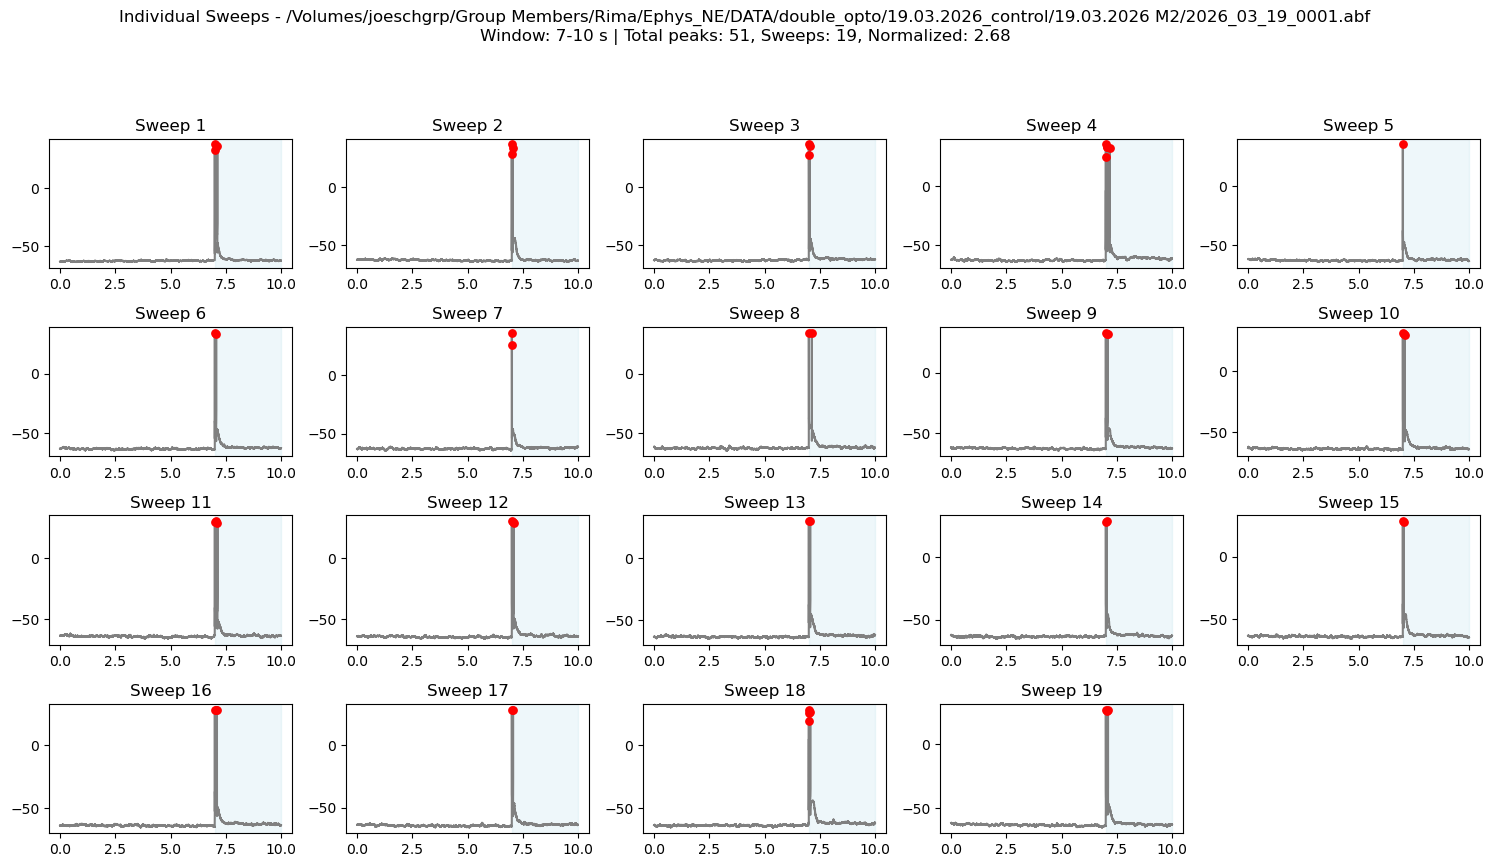

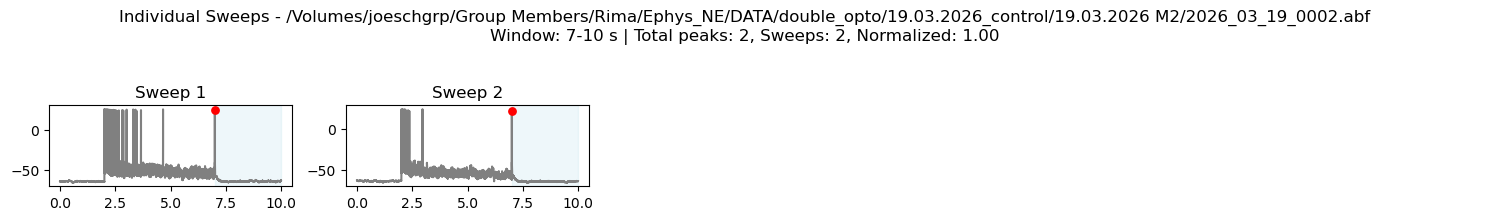

' df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )\ncsv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"\ndf.to_csv(csv_file_path, index=False)\n\nprint(f"Results saved to {csv_file_path}")\ndf '

In [2]:
base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/19.03.2026_control"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0001.abf"),
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0002.abf")
]
def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(7, 10),
):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    # Layout similar to your previous output
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    peak_counts = []
    total_peaks = 0

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        x_window = x[window_mask]
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        n_peaks = len(peaks)
        peak_counts.append(n_peaks)
        total_peaks += n_peaks

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}")

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    plt.suptitle(
        f"Individual Sweeps - {abf_file}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return abf_file, norm_spikes, peak_counts

# Process each file, visualize peaks per sweep, and collect summary
results = []
for abf_file in abf_files:
    file_path, norm_spikes, peak_counts = count_and_plot_peaks_per_sweep(
        abf_file, height_threshold=5, detection_window=(7, 10)
    )
    results.append([file_path, f"{norm_spikes:.2f}", peak_counts])

df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"])

# Save summary to CSV
""" df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )
csv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"
df.to_csv(csv_file_path, index=False)

print(f"Results saved to {csv_file_path}")
df """

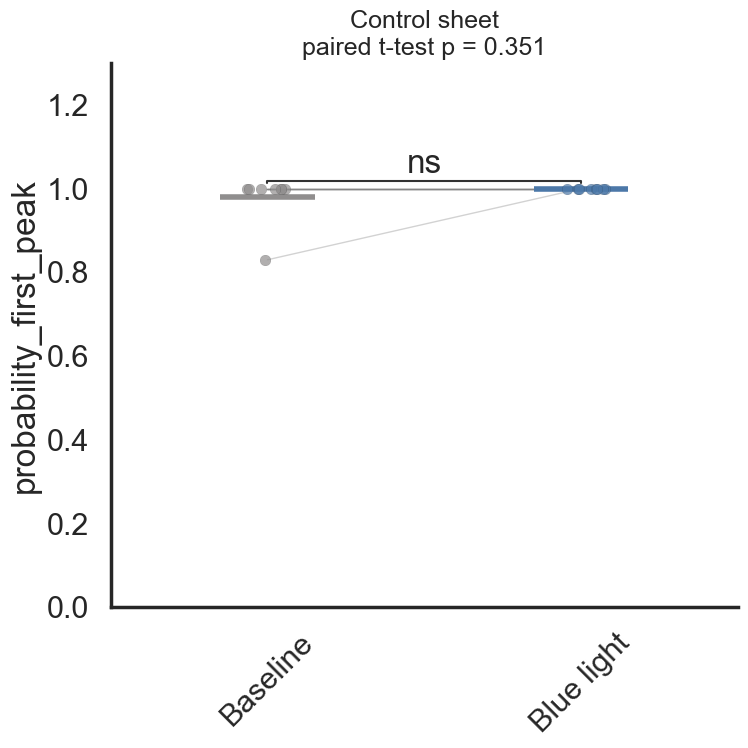

,Cell_ID,Baseline_Value,Blue_Value,Delta,Percent_Change
0,1,1.0,1.0,0.0,0.0
1,2,1.0,1.0,0.0,0.0
2,3,1.0,1.0,0.0,0.0
3,4,1.0,1.0,0.0,0.0
4,5,1.0,1.0,0.0,0.0


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database.xlsx"
sheet_name = "Control"

id_col = "ID"
condition_col = "condition"
value_col = "probability_first_peak"
alternate_value_col = "probability_first_peak" #"normalized all peaks"

baseline_label = "baseline"
blue_label = "blue light"
y_label = "probability_first_peak"

# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    if value_col not in df.columns and alternate_value_col in df.columns:
        value_col = alternate_value_col
    if value_col not in df.columns:
        raise KeyError(f"Missing value column: {value_col}\nAvailable: {list(df.columns)}")

    if 'comment' in df.columns:
        exclude_mask = df['comment'].astype(str).str.contains('Exclude', case=False, na=False)
        df = df.loc[~exclude_mask].copy()

    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == baseline_label][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Value'})
    blue_rows = df[cond.str.contains('blue light', na=False)][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Blue_Value'})

    baseline_rows['Baseline_Value'] = pd.to_numeric(baseline_rows['Baseline_Value'], errors='coerce')
    blue_rows['Blue_Value'] = pd.to_numeric(blue_rows['Blue_Value'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Value'].mean()
    blue_agg = blue_rows.groupby('Cell_ID', as_index=False)['Blue_Value'].mean()

    paired = pd.merge(baseline_agg, blue_agg, on='Cell_ID', how='inner')
    paired['Delta'] = paired['Blue_Value'] - paired['Baseline_Value']
    paired['Percent_Change'] = np.where(
        paired['Baseline_Value'] != 0,
        paired['Delta'] / paired['Baseline_Value'] * 100,
        np.nan,
    )
    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df['Baseline_Value'], paired_df['Blue_Value'], nan_policy='omit')
    try:
        wilcoxon_p = stats.wilcoxon(paired_df['Baseline_Value'], paired_df['Blue_Value']).pvalue
    except ValueError:
        wilcoxon_p = np.nan
    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# PLOTTING
# =============================================================================

def paired_plot(ax, data, title):
    conditions = ['Baseline', 'Blue light']
    colors_fill = ['lightgrey', 'lightskyblue']
    colors_points = ['#908E8E', '#4C78A8']
    jitter_amount = 0.08
    rng = np.random.default_rng(42)

    box_data = [data['Baseline_Value'].values, data['Blue_Value'].values]
    bp = ax.boxplot(
        box_data,
        positions=[0, 1],
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='none'),
        boxprops=dict(edgecolor='none'),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
    )

    for patch, color in zip(bp['boxes'], colors_fill):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        x0 = 0 + rng.uniform(-jitter_amount, jitter_amount)
        x1 = 1 + rng.uniform(-jitter_amount, jitter_amount)
        ax.plot([0, 1], [row['Baseline_Value'], row['Blue_Value']], color='gray', alpha=0.35, linewidth=1)
        ax.scatter(x0, row['Baseline_Value'], color=colors_points[0], alpha=0.7, s=60, edgecolors='black', linewidths=0.1, zorder=3)
        ax.scatter(x1, row['Blue_Value'], color=colors_points[1], alpha=0.7, s=60, edgecolors='black', linewidths=0.1, zorder=3)

    for i, col in enumerate(['Baseline_Value', 'Blue_Value']):
        ax.hlines(data[col].mean(), i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    long_df = pd.DataFrame({
        'value': np.concatenate([data['Baseline_Value'], data['Blue_Value']]),
        'group': ['Baseline'] * len(data) + ['Blue light'] * len(data),
    })

    annotator = Annotator(ax, [('Baseline', 'Blue light')], data=long_df, x='group', y='value')
    annotator.configure(test='t-test_paired', text_format='star', loc='outside', verbose=False)
    annotator.apply_and_annotate()

    ymax = max(data['Baseline_Value'].max(), data['Blue_Value'].max())
    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, ymax * 1.3 if ymax > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=0)
paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col=condition_col, value_col=value_col)
paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"Control sheet\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

pd.options.display.max_columns = None
display(paired_df.head())


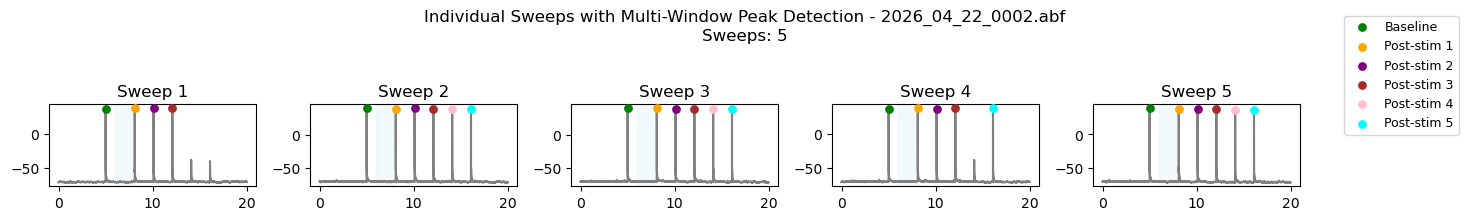

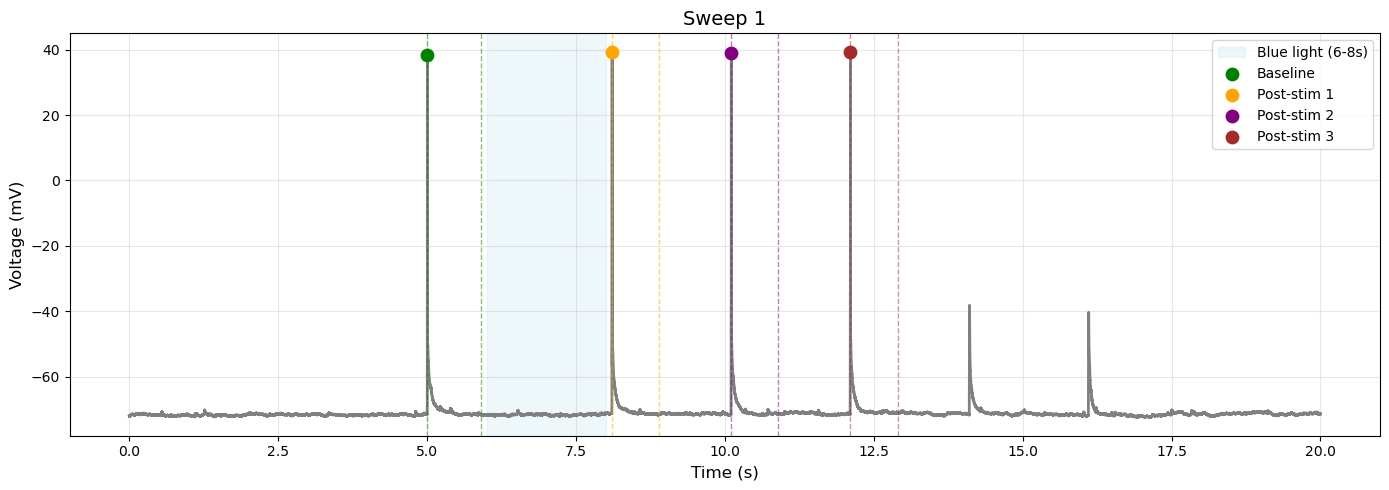

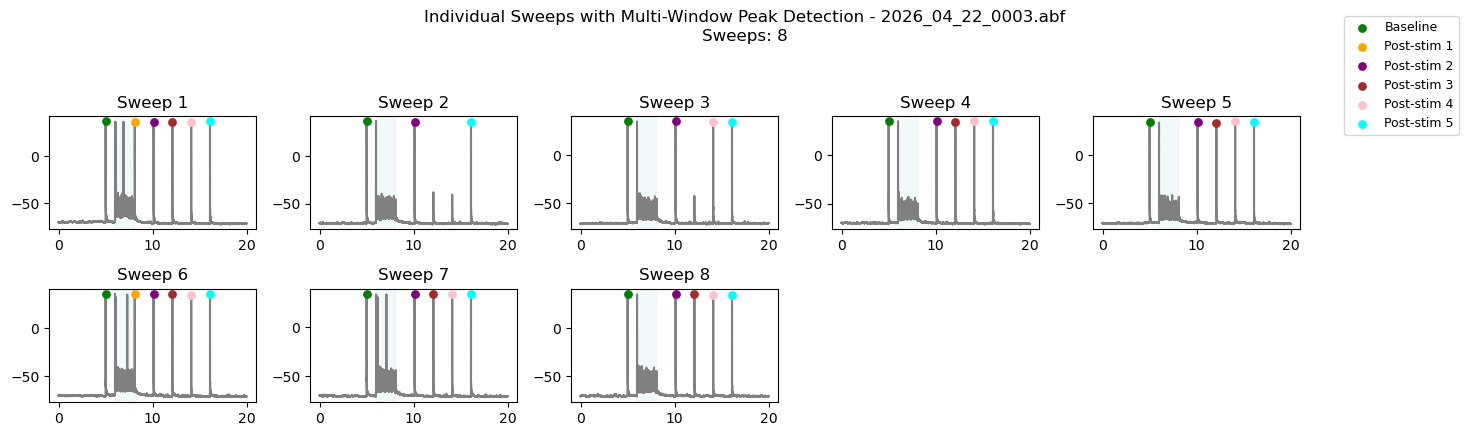

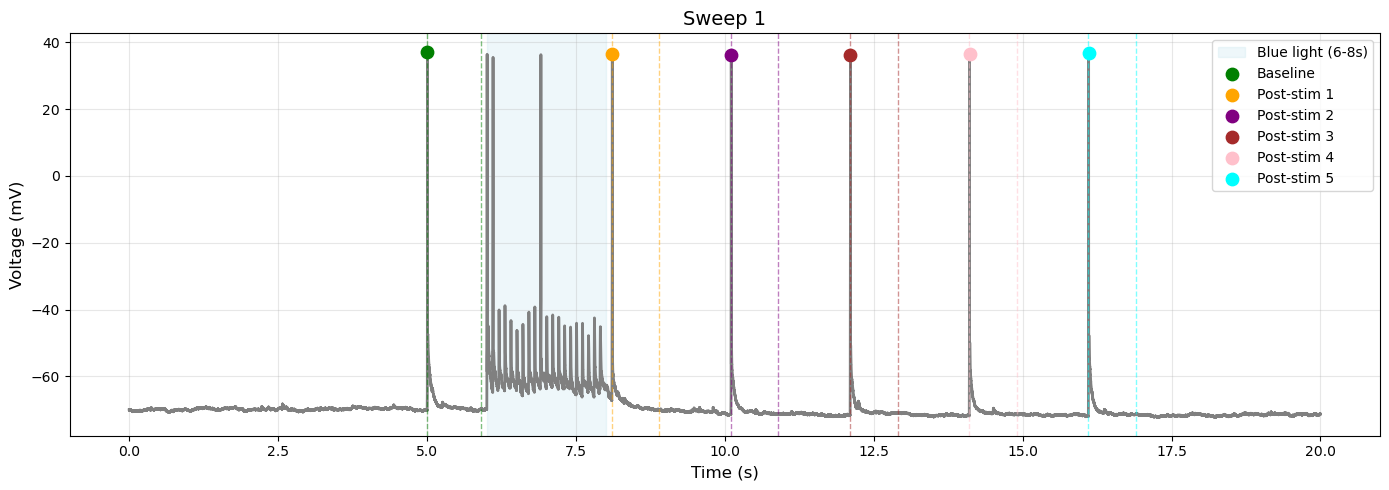

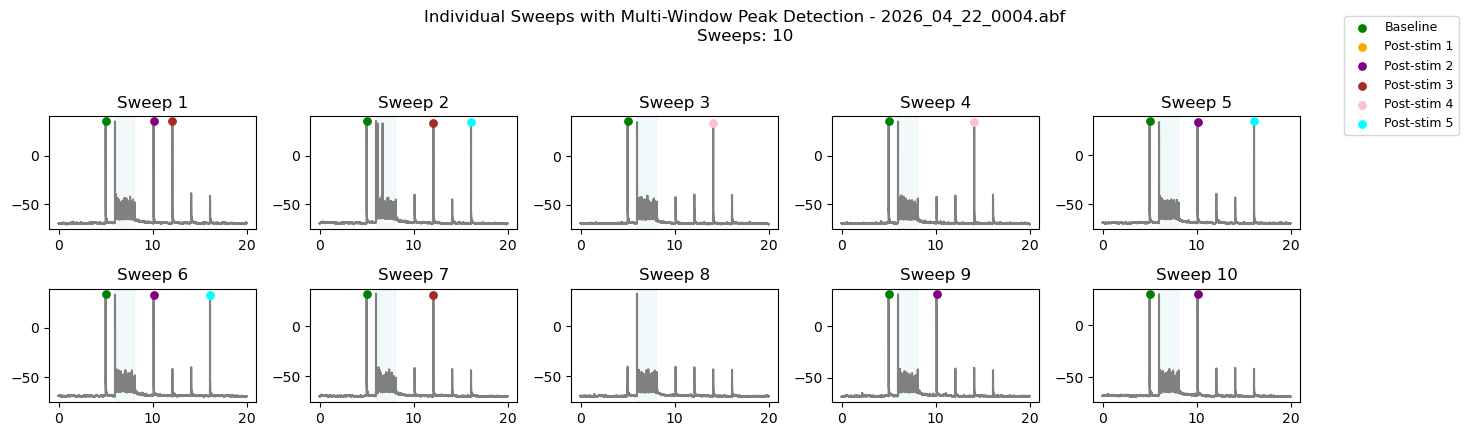

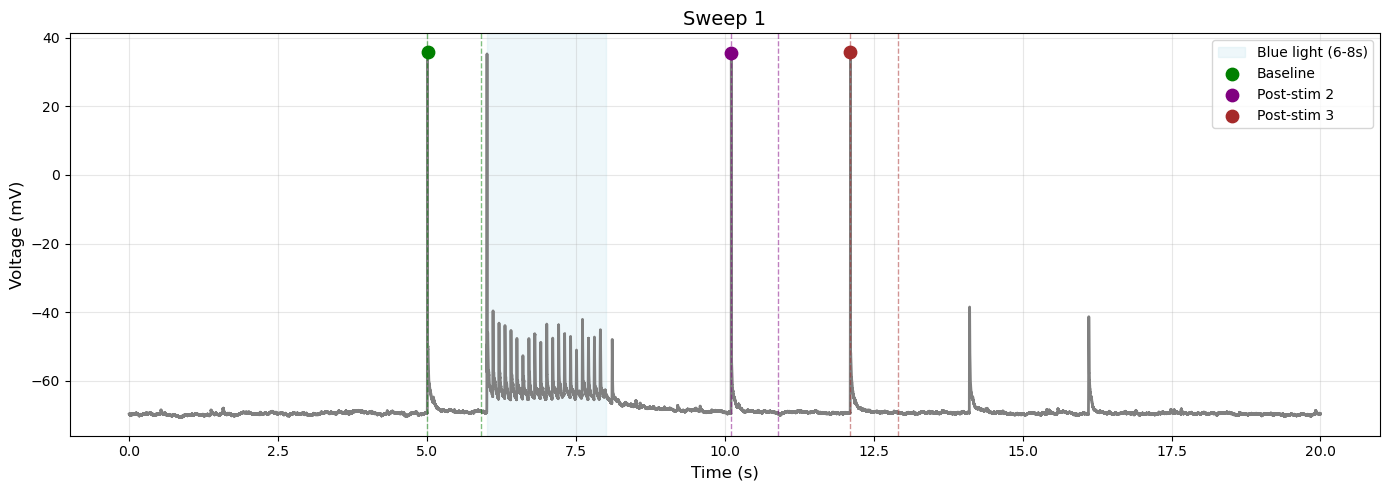

,File,Baseline avg,Baseline sweep1,Post-stim 1 avg,Post-stim 1 sweep1,Post-stim 2 avg,Post-stim 2 sweep1,Post-stim 3 avg,Post-stim 3 sweep1,Post-stim 4 avg,Post-stim 4 sweep1,Post-stim 5 avg,Post-stim 5 sweep1
0,2026_04_22_0002.abf,1.00,1,1.00,1,1.00,1,1.00,1,0.60,0,0.80,0
1,2026_04_22_0003.abf,1.00,1,0.25,1,1.00,1,0.75,1,0.88,1,1.00,1
2,2026_04_22_0004.abf,0.90,1,0.00,0,0.50,1,0.30,1,0.20,0,0.30,0


In [10]:
base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "22.04.2026 M3/2026_04_22_0002.abf"),
    os.path.join(base_dir, "22.04.2026 M3/2026_04_22_0003.abf"),
    os.path.join(base_dir, "22.04.2026 M3/2026_04_22_0004.abf")
]

# Define time windows for each stimulus phase
# Format: (start, end, label, color)
stimulus_windows = [
    (5.0, 5.9, "Baseline", "green"),
    (8.1, 8.9, "Post-stim 1", "orange"),
    (10.1, 10.9, "Post-stim 2", "purple"),
    (12.1, 12.9, "Post-stim 3", "brown"),
    (14.1, 14.9, "Post-stim 4", "pink"),
    (16.1, 16.9, "Post-stim 5", "cyan"),
]

def count_and_plot_peaks_multi_window(
    abf_file,
    stimulus_windows,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    sweep_to_zoom=0,
    show_grid=True,
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    # Layout similar to your previous output
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    # Dictionary to store peak counts per window per sweep
    peak_counts_by_window = {label: [] for _, _, label, _ in stimulus_windows}
    total_peaks_by_window = {label: 0 for _, _, label, _ in stimulus_windows}

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=1.5)

        # Highlight blue light window (6-8s)
        ax.axvspan(6.0, 8.0, color="lightblue", alpha=0.15, label="Blue light")

        # Process each stimulus window
        for start, end, label, color in stimulus_windows:
            window_mask = (x >= start) & (x <= end)
            x_window = x[window_mask]
            y_window = y[window_mask]

            if y_window.size > 0:
                peaks_window, _ = detect_peaks(
                    y_window,
                    height_threshold=height_threshold,
                    prominence_min=prominence_min,
                    distance_min=distance_min,
                )
                peaks = np.where(window_mask)[0][peaks_window]
            else:
                peaks = np.array([], dtype=int)

            n_peaks = len(peaks)
            peak_counts_by_window[label].append(n_peaks)
            total_peaks_by_window[label] += n_peaks

            # Plot peaks with window-specific color
            if n_peaks > 0:
                ax.scatter(x[peaks], y[peaks], color=color, s=28, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}")

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    # Create legend with window labels and colors
    legend_elements = [
        plt.scatter([], [], color=color, s=28, label=label)
        for _, _, label, color in stimulus_windows
    ]
    fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=9)

    plt.suptitle(
        f"Individual Sweeps with Multi-Window Peak Detection - {os.path.basename(abf_file)}\n"
        f"Sweeps: {n_sweeps}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 0.88, 0.93])
    plt.show()

    # Create large detailed plot of sweep `sweep_to_zoom` (default 0)
    zoom_idx = max(0, min(sweep_to_zoom, n_sweeps-1))
    fig_zoom, ax_zoom = plt.subplots(figsize=(14, 5))

    abf.setSweep(zoom_idx)
    x_sweep1 = abf.sweepX
    y_sweep1 = abf.sweepY

    ax_zoom.plot(x_sweep1, y_sweep1, color="gray", linewidth=2.0)

    # Highlight blue light window (6-8s)
    ax_zoom.axvspan(6.0, 8.0, color="lightblue", alpha=0.2, label="Blue light (6-8s)")

    # Process and plot peaks for each stimulus window
    for start, end, label, color in stimulus_windows:
        window_mask = (x_sweep1 >= start) & (x_sweep1 <= end)
        x_window = x_sweep1[window_mask]
        y_window = y_sweep1[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        if len(peaks) > 0:
            ax_zoom.scatter(x_sweep1[peaks], y_sweep1[peaks], color=color, s=80, zorder=3, label=label)
            # Add vertical lines to highlight stimulus windows
            ax_zoom.axvline(start, color=color, linestyle="--", alpha=0.5, linewidth=1)
            ax_zoom.axvline(end, color=color, linestyle="--", alpha=0.5, linewidth=1)

    ax_zoom.set_xlabel("Time (s)", fontsize=12)
    ax_zoom.set_ylabel("Voltage (mV)", fontsize=12)
    ax_zoom.set_title(f"Sweep {zoom_idx+1}", fontsize=14)
    ax_zoom.legend(loc="upper right", fontsize=10)
    if show_grid:
        ax_zoom.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return abf_file, peak_counts_by_window, total_peaks_by_window

# Process each file
results_multi_window = []
for abf_file in abf_files:
    file_path, peak_counts_by_window, total_peaks_by_window = count_and_plot_peaks_multi_window(
        abf_file, stimulus_windows, height_threshold=5, sweep_to_zoom=0
    )
    results_multi_window.append({
        "file": os.path.basename(abf_file),
        "peak_counts_by_window": peak_counts_by_window,
        "total_peaks_by_window": total_peaks_by_window,
    })

# Create summary table: normalized peak count per stimulus window + sweep-1 counts
summary_data = []
for result in results_multi_window:
    row = {"File": result["file"]}
    # number of sweeps for this file (derived from lists)
    if len(result["peak_counts_by_window"])>0:
        n_sweeps = len(next(iter(result["peak_counts_by_window"].values())))
    else:
        n_sweeps = 0
    for _, _, label, _ in stimulus_windows:
        total = result["total_peaks_by_window"].get(label, 0)
        avg = total / n_sweeps if n_sweeps>0 else 0
        # sweep1 (first sweep) count for this label
        sweep1_count = result["peak_counts_by_window"].get(label, [0])[0] if n_sweeps>0 else 0
        row[f"{label} avg"] = f"{avg:.2f}"
        row[f"{label} sweep1"] = int(sweep1_count)
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary

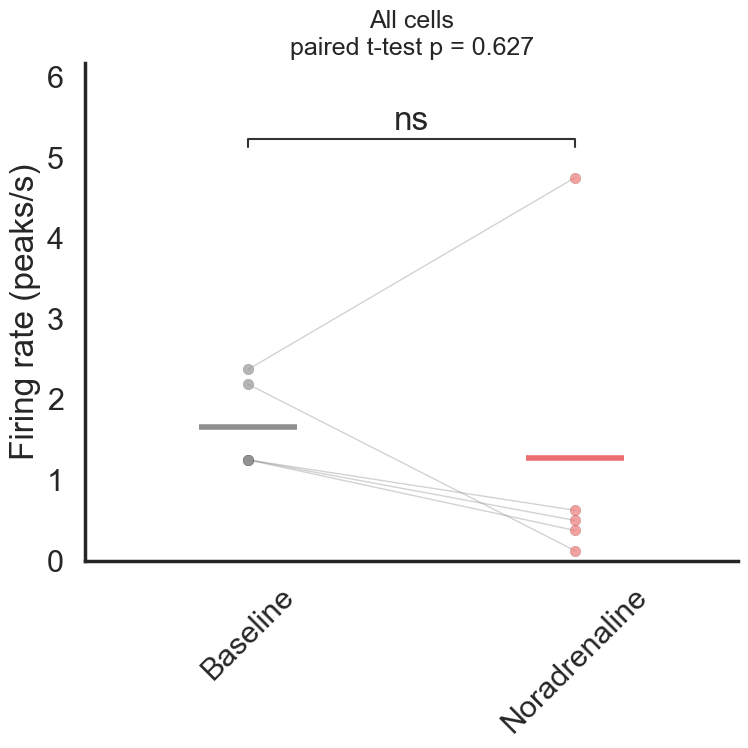

,Cell_ID,Baseline_Counts,NA_Counts,Baseline_FR,NA_FR,Delta_FR,Percent_Change,Fold_Change
0,1,1.00,0.3,1.2500,0.375,-0.8750,-70.000000,0.300000
1,2,1.75,0.1,2.1875,0.125,-2.0625,-94.285714,0.057143
2,3,1.90,3.8,2.3750,4.750,2.3750,100.000000,2.000000
3,4,1.00,0.4,1.2500,0.500,-0.7500,-60.000000,0.400000
4,5,1.00,0.5,1.2500,0.625,-0.6250,-50.000000,0.500000


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS 
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database.xlsx"
sheet_name = "Noradrenaline"

id_col = "ID"
# we'll extract post_stim_3_avg for both baseline and NA conditions
poststim_col = "post_stim_3_avg"

# time window (s) over which counts were measured
time_window = 0.8

baseline_label = "Baseline"
na_label = "Noradrenaline"

y_label = "Firing rate (peaks/s)"


# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    # Select rows for baseline and noradrenaline conditions and take mean per ID
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    # normalize condition strings for matching
    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == 'baseline'][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Counts'})
    na_rows = df[cond.str.contains('noradrenaline')][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'NA_Counts'})

    # coerce numeric and groupby mean in case of duplicates
    baseline_rows['Baseline_Counts'] = pd.to_numeric(baseline_rows['Baseline_Counts'], errors='coerce')
    na_rows['NA_Counts'] = pd.to_numeric(na_rows['NA_Counts'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Counts'].mean()
    na_agg = na_rows.groupby('Cell_ID', as_index=False)['NA_Counts'].mean()

    # merge on Cell_ID — keep only cells that have both baseline and NA
    paired = pd.merge(baseline_agg, na_agg, on='Cell_ID', how='inner')

    # compute firing rates (peaks per second) from counts-per-sweep
    paired['Baseline_FR'] = paired['Baseline_Counts'] / time_window
    paired['NA_FR'] = paired['NA_Counts'] / time_window

    paired['Delta_FR'] = paired['NA_FR'] - paired['Baseline_FR']
    paired['Percent_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['Delta_FR'] / paired['Baseline_FR'] * 100,
        np.nan,
    )
    paired['Fold_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['NA_FR'] / paired['Baseline_FR'],
        np.nan,
    )

    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df["Baseline_FR"], paired_df["NA_FR"], nan_policy="omit")

    try:
        wilcoxon_result = stats.wilcoxon(paired_df["Baseline_FR"], paired_df["NA_FR"])
        wilcoxon_p = wilcoxon_result.pvalue
    except ValueError:
        wilcoxon_p = np.nan

    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# MAIN PAIRED PLOT 
# =============================================================================

def paired_plot(ax, data, title):
    conditions = [baseline_label, na_label]
    colors_fill = ["lightgrey", "lightcoral"]
    colors_points = ["#908E8E", "#EB6F6F"]

    box_data = [data["Baseline_FR"].values, data["NA_FR"].values]

    ax.boxplot(
        box_data,
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="none"),
        boxprops=dict(facecolor="none", edgecolor="none"),
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
    )

    for i, patch in enumerate(ax.artists):
        patch.set_facecolor(colors_fill[i])
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        y = [row["Baseline_FR"], row["NA_FR"]]
        x = [0, 1]

        ax.plot(x, y, color="gray", alpha=0.35, linewidth=1)

        for j, yi in enumerate(y):
            ax.scatter(
                x[j], yi,
                color=colors_points[j],
                alpha=0.65,
                s=60,
                edgecolors="black",
                linewidths=0.1,
                zorder=3,
            )

    for i, col in enumerate(["Baseline_FR", "NA_FR"]):
        mean_y = data[col].mean()
        ax.hlines(mean_y, i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    plot_long = pd.DataFrame({
        "value": np.concatenate([data["Baseline_FR"], data["NA_FR"]]),
        "group": [baseline_label] * len(data) + [na_label] * len(data),
    })

    annotator = Annotator(ax, [(baseline_label, na_label)], data=plot_long, x="group", y="value")
    annotator.configure(test="t-test_paired", text_format="star", loc="outside", verbose=False)
    annotator.apply_and_annotate()

    max_y = max(data["Baseline_FR"].max(), data["NA_FR"].max())

    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, max_y * 1.3 if max_y > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=1)

paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col='condition', value_col=poststim_col)

paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"All cells\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

# show both counts and firing rates for verification
pd.options.display.max_columns = None
display(paired_df.head())


FOR 10 pA CURRENT CLAMP ANALYSIS (SAME MICE WHERE COULD NOT INIATE CHRIMSON OPTO RESPONSE)

In [19]:
import numpy as np
import pyabf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from ephys_functions import detect_peaks

sns.set_context("talk")
sns.set_style("white")

base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026"

abf_files = [
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0021.abf"),
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0026.abf"),
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0027.abf"),
    os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0006.abf"),
    os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0007.abf")
]

results_output_path = os.path.join(base_dir, "fi_results_table.csv")

def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(2.5, 10.0),
    current_start_pA=0,
    current_step_pA=10,
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)
    window_seconds = detection_window[1] - detection_window[0]

    if window_seconds <= 0:
        raise ValueError("detection_window must have end > start")

    per_sweep = []

    # Figure 1: original sweep layout with peaks marked
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))
    fig_sweeps, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    for sweep in abf.sweepList:
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
            n_peaks = int(len(peaks_window))
        else:
            peaks = np.array([], dtype=int)
            n_peaks = 0

        firing_rate_hz = n_peaks / window_seconds
        current_pA = current_start_pA + sweep * current_step_pA

        per_sweep.append({
            "File": os.path.basename(abf_file),
            "Sweep": int(sweep + 1),
            "Current_pA": float(current_pA),
            "Peaks_in_Window": n_peaks,
            "FiringRate_Hz": float(firing_rate_hz),
        })

        ax = axes[sweep]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)
        ax.set_title(f"Sweep {sweep + 1}")

    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    total_peaks = int(sum(item["Peaks_in_Window"] for item in per_sweep))
    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    fig_sweeps.suptitle(
        f"Individual Sweeps - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    fig_sweeps.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # Figure 2: FI curve for this file
    sweep_df = pd.DataFrame(per_sweep)
    fig_fi, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sweep_df["Current_pA"], sweep_df["FiringRate_Hz"], marker="o", linewidth=2)
    ax.set_xlabel("Current injection (pA)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.set_title(
        f"FI curve - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return sweep_df


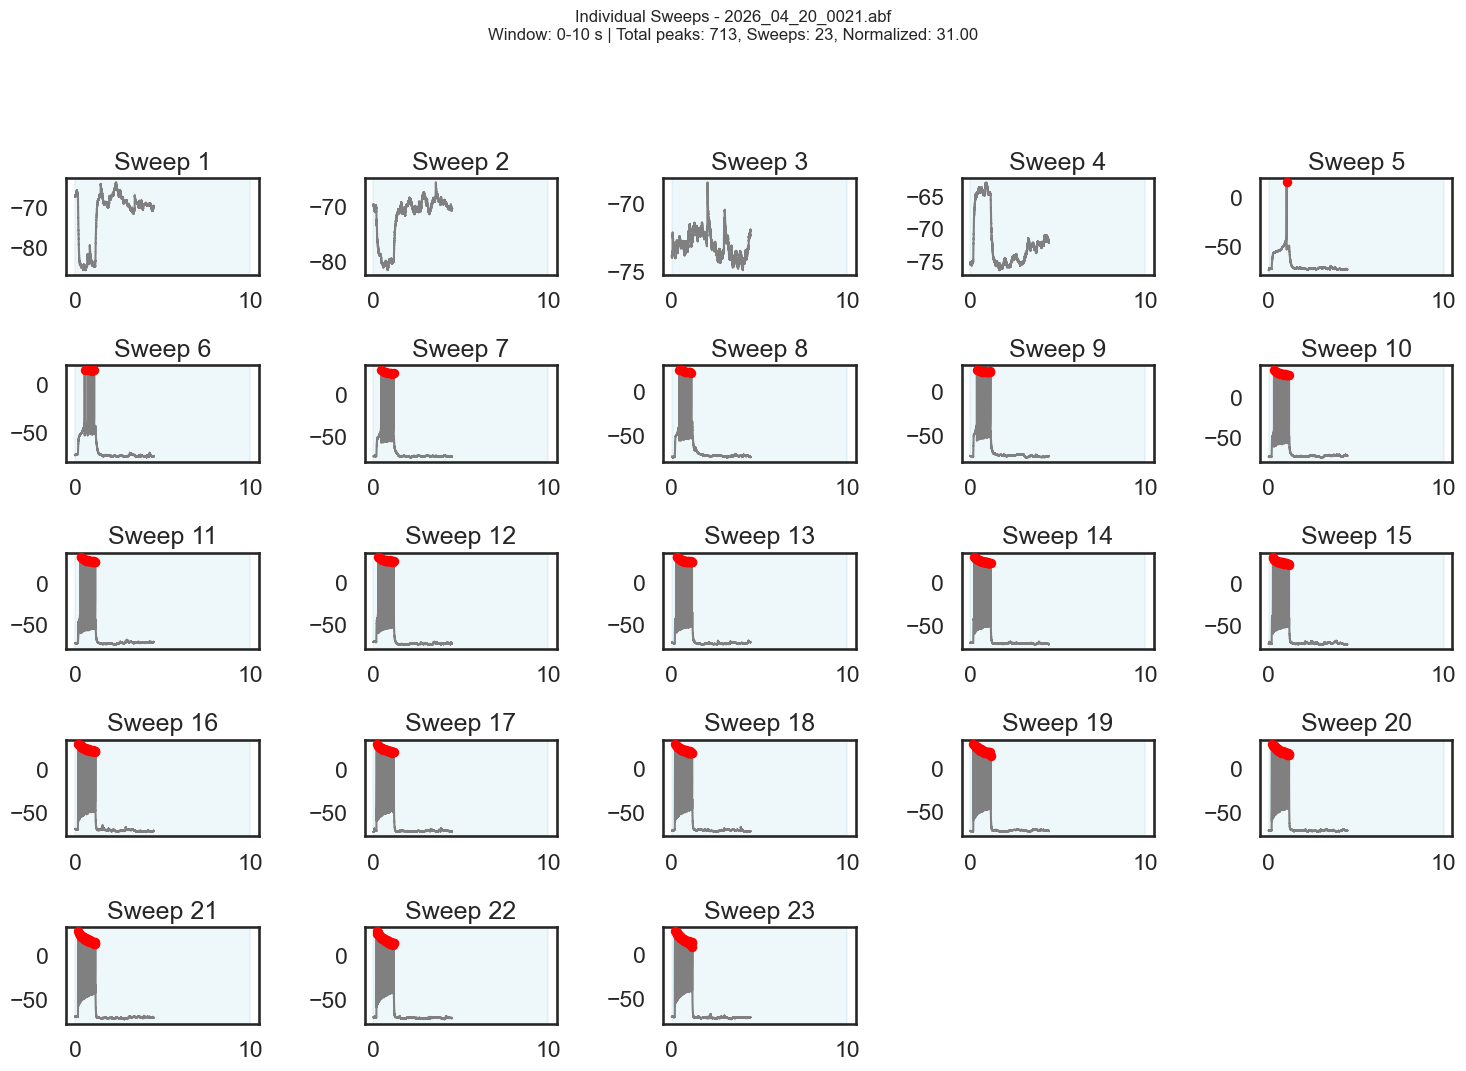

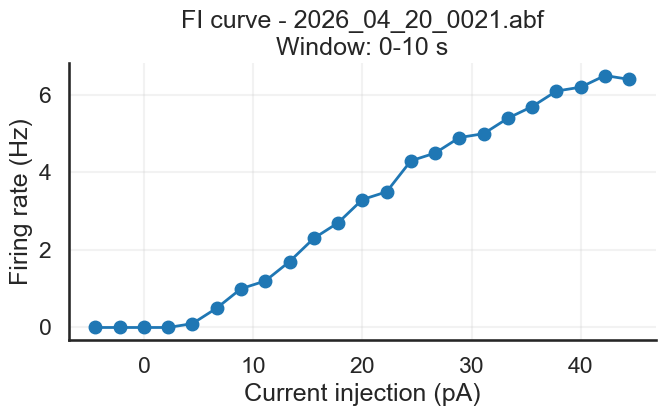

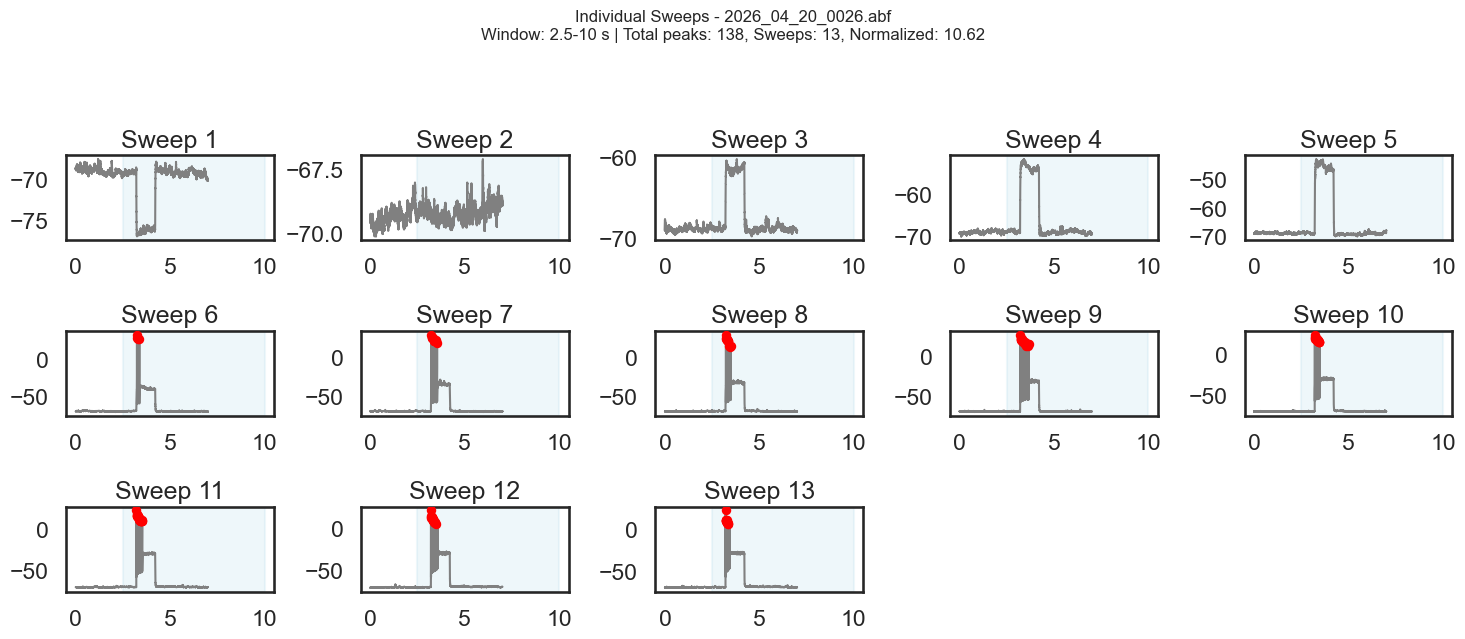

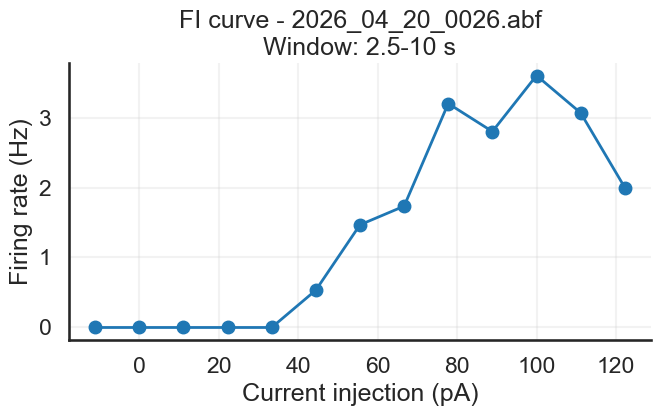

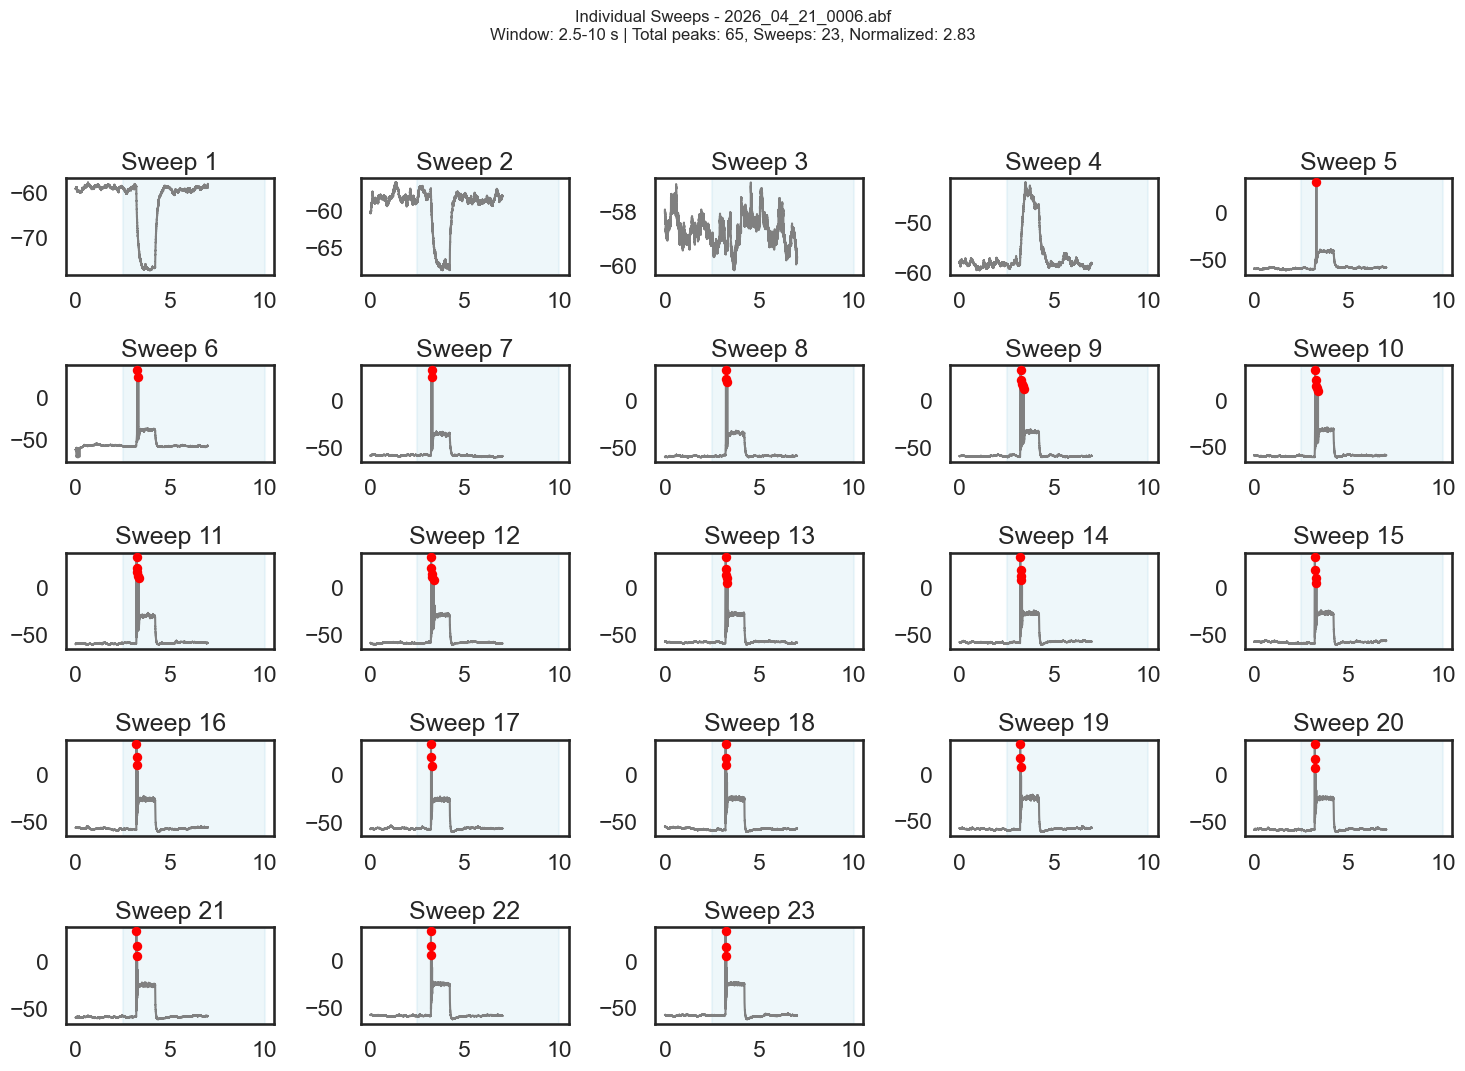

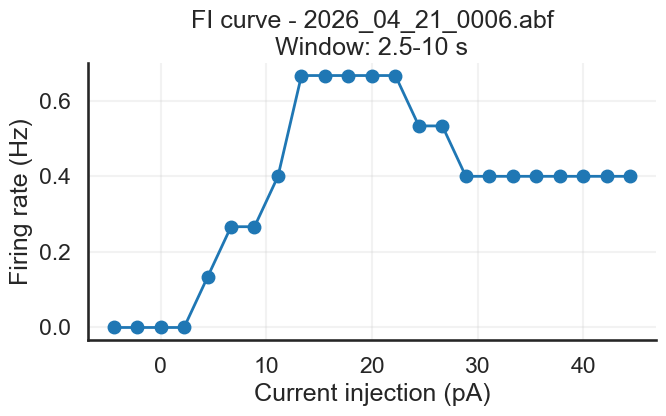

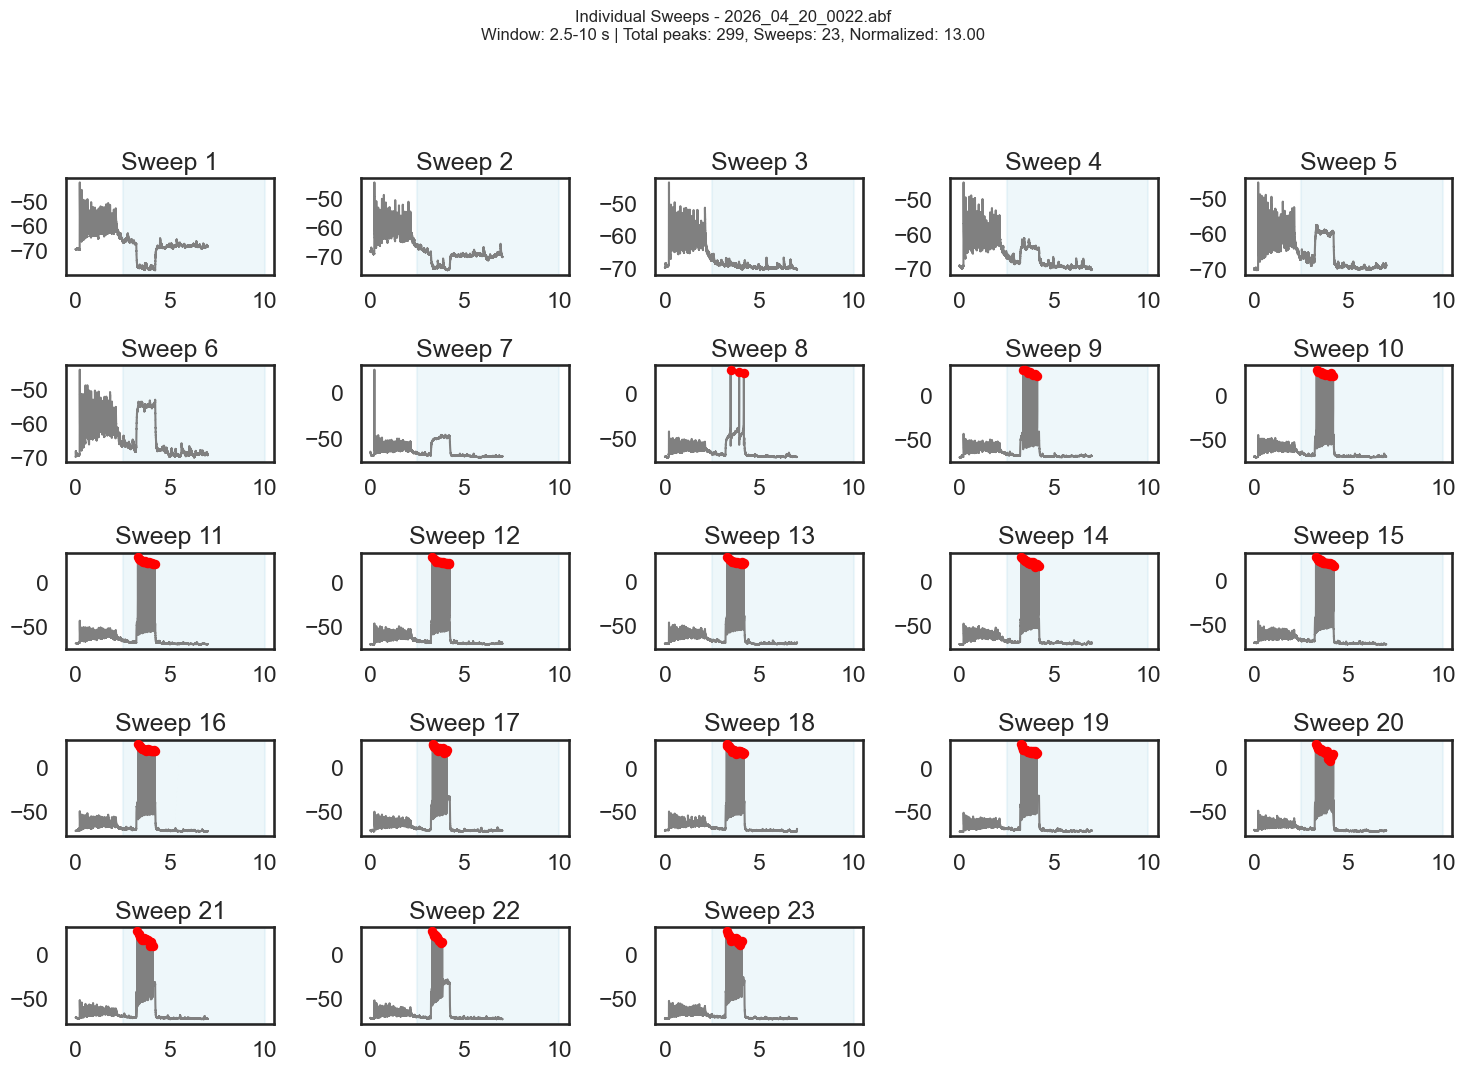

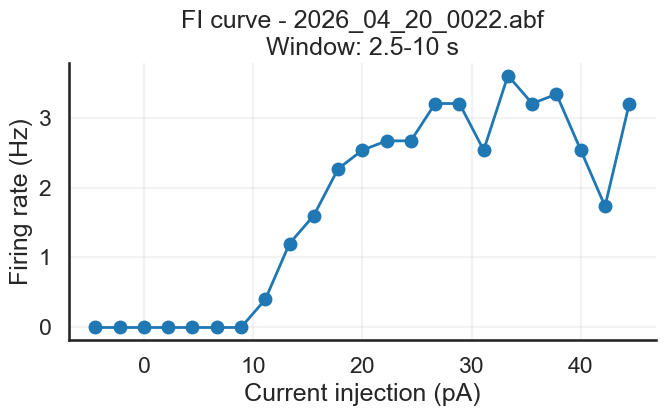

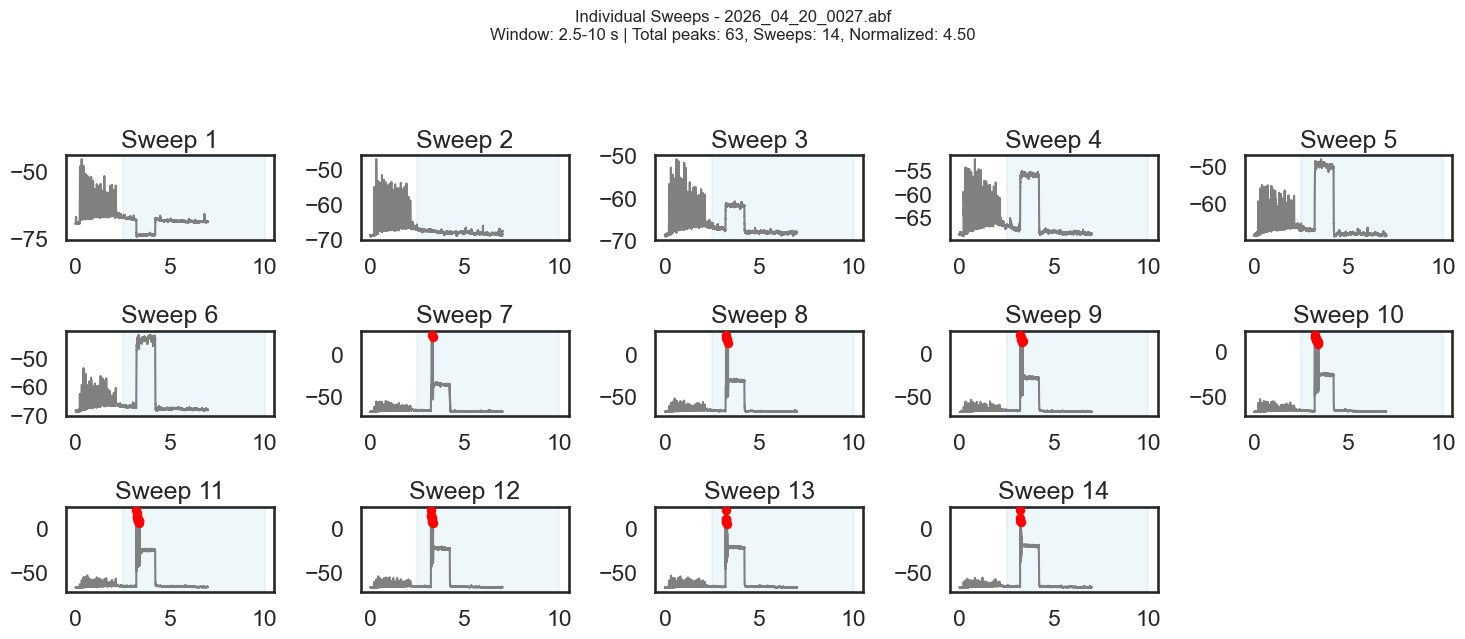

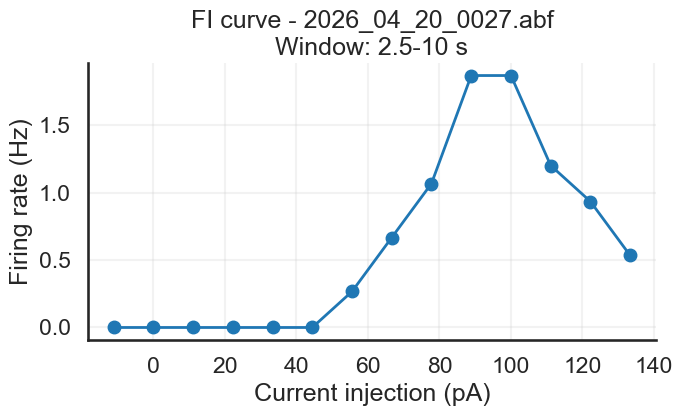

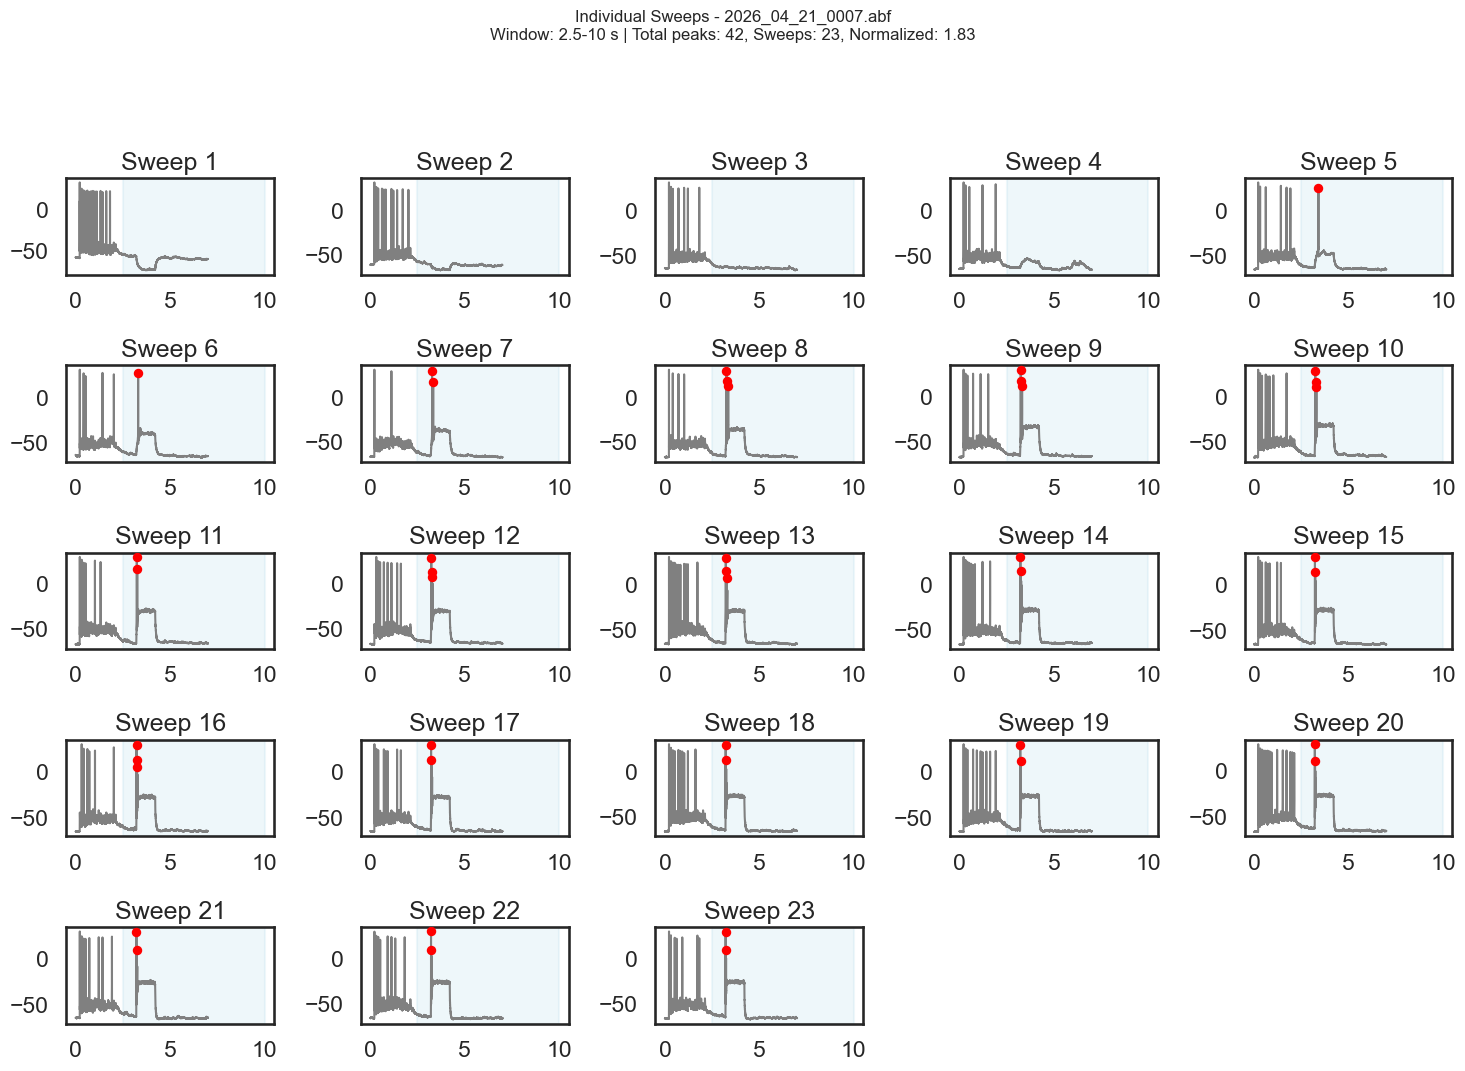

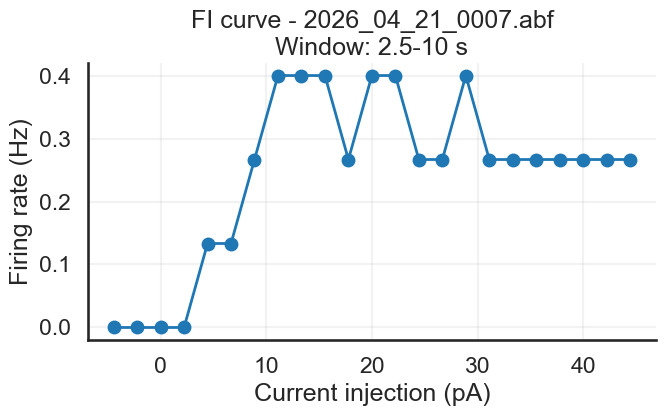

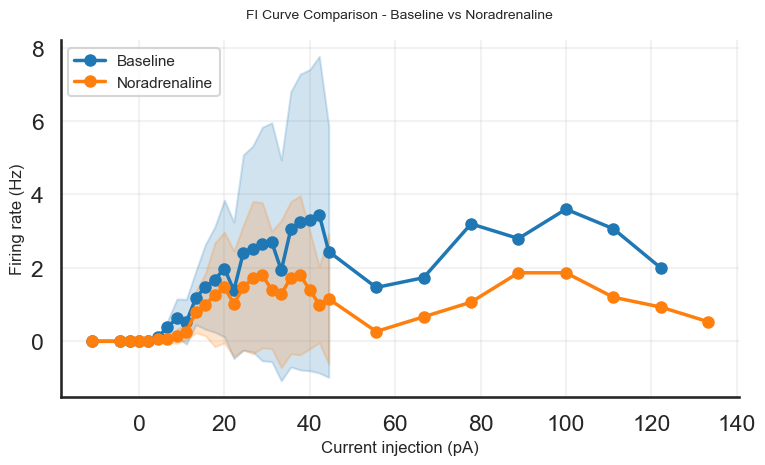

OSError: Cannot save file into a non-existent directory: '/Users/rbondare/rbondare/ephys/results'

In [22]:
import numpy as np
import pyabf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from ephys_functions import detect_peaks

sns.set_context("talk")
sns.set_style("white")

base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026"

# Dictionary to organize files by condition with their detection windows
abf_files_dict = {
    "baseline": [
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0021.abf"), "detection_window": (0, 10)},
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0026.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0006.abf"), "detection_window": (2.5, 10)}
    ],
    "noradrenaline": [
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0022.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0027.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0007.abf"), "detection_window": (2.5, 10)}
    ]
}

results_output_path = os.path.expanduser("~/rbondare/ephys/results/fi_results_table.csv")

def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(2.5, 10.0),
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)
    window_seconds = detection_window[1] - detection_window[0]

    if window_seconds <= 0:
        raise ValueError("detection_window must have end > start")

    per_sweep = []

    # Figure 1: original sweep layout with peaks marked
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))
    fig_sweeps, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    for sweep in abf.sweepList:
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
            n_peaks = int(len(peaks_window))
        else:
            peaks = np.array([], dtype=int)
            n_peaks = 0

        firing_rate_hz = n_peaks / window_seconds
        
        # Extract actual current from stimulus channel (sweepC)
        # Take the mean value during the detection window as the injected current
        current_window = abf.sweepC[window_mask]
        if current_window.size > 0:
            current_pA = float(np.mean(current_window))
        else:
            current_pA = float(current_start_pA + sweep * current_step_pA)

        per_sweep.append({
            "File": os.path.basename(abf_file),
            "Sweep": int(sweep + 1),
            "Current_pA": current_pA,
            "Peaks_in_Window": n_peaks,
            "FiringRate_Hz": float(firing_rate_hz),
        })

        ax = axes[sweep]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)
        ax.set_title(f"Sweep {sweep + 1}")

    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    total_peaks = int(sum(item["Peaks_in_Window"] for item in per_sweep))
    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    fig_sweeps.suptitle(
        f"Individual Sweeps - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    fig_sweeps.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # Figure 2: FI curve for this file
    sweep_df = pd.DataFrame(per_sweep)
    fig_fi, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sweep_df["Current_pA"], sweep_df["FiringRate_Hz"], marker="o", linewidth=2)
    ax.set_xlabel("Current injection (pA)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.set_title(
        f"FI curve - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return sweep_df


def plot_fi_curves_comparison(
    abf_files_dict,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    ):
    """
    Process multiple files for different conditions and plot mean FI curves.
    
    Parameters:
    -----------
    abf_files_dict : dict
        Dictionary with condition names as keys and lists of dicts as values
        Each dict should contain "file" (path) and "detection_window" (tuple)
        e.g., {"baseline": [{"file": "path.abf", "detection_window": (0, 10)}, ...]}
    """
    all_results = []
    condition_data = {}
    
    # Process all files and collect results
    for condition, abf_file_list in abf_files_dict.items():
        condition_dfs = []
        
        for file_dict in abf_file_list:
            abf_file = file_dict["file"]
            detection_window = file_dict["detection_window"]
            
            sweep_df = count_and_plot_peaks_per_sweep(
                abf_file,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
                detection_window=detection_window,
            )
            sweep_df["Condition"] = condition
            condition_dfs.append(sweep_df)
            all_results.append(sweep_df)
        
        # Combine all files for this condition
        condition_combined = pd.concat(condition_dfs, ignore_index=True)
        condition_data[condition] = condition_combined
    
    # Calculate mean firing rate per current level for each condition
    fig_comparison, ax = plt.subplots(figsize=(8, 5))
    colors = {"baseline": "#1f77b4", "noradrenaline": "#ff7f0e"}
    
    for condition, df in condition_data.items():
        # Group by current and calculate mean firing rate
        mean_fr = df.groupby("Current_pA")["FiringRate_Hz"].mean()
        std_fr = df.groupby("Current_pA")["FiringRate_Hz"].std()
        
        ax.plot(
            mean_fr.index,
            mean_fr.values,
            marker="o",
            linewidth=2.5,
            label=condition.capitalize(),
            color=colors.get(condition, None),
            markersize=8
        )
        ax.fill_between(
            mean_fr.index,
            mean_fr.values - std_fr.values,
            mean_fr.values + std_fr.values,
            alpha=0.2,
            color=colors.get(condition, None)
        )
    
    ax.set_xlabel("Current injection (pA)", fontsize=12)
    ax.set_ylabel("Firing rate (Hz)", fontsize=12)
    ax.set_title(
        f"FI Curve Comparison - Baseline vs Noradrenaline\n",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=11, loc="upper left")
    plt.tight_layout()
    plt.show()
    
    # Combine all results and save to CSV
    full_results_df = pd.concat(all_results, ignore_index=True)
    full_results_df.to_csv(results_output_path, index=False)
    print(f"Results saved to {results_output_path}")
    
    return full_results_df, condition_data


# Main execution
if __name__ == "__main__":
    all_results, condition_data = plot_fi_curves_comparison(
        abf_files_dict,
        height_threshold=5,
        prominence_min=0.1,
        distance_min=5,
    )